In [44]:
import os
os.environ['OMP_NUM_THREADS'] = '1'
os.environ['MKL_NUM_THREADS'] = '1'
os.environ['OPENBLAS_NUM_THREADS'] = '1'
import sys
from pathlib import Path
# Add project root to sys.path
project_root = str(Path().cwd().resolve())
if "notebooks" in project_root:
    project_root = str(Path().cwd().parent.resolve())
if project_root not in sys.path:
    sys.path.append(project_root)
    

In [45]:
import pandas as pd
import numpy as np
from pathlib import Path

# Import Factor Classes
from factors.momentum.ts_momentum import TimeSeriesMomentum
from factors.momentum.reversal import ShortTermReversal
from factors.risk.volatility import HistoricalVolatility
from factors.volume.volume_shock import VolumeShock
from factors.fundamental.f_score import PiotroskiFScore
from factors.fundamental.accruals import Accruals
from factors.fundamental.growth_yoy import ProfitabilityGrowth
from factors.fundamental.size import SmallCap

# Import Aligner and Combiner
from core.data_fetcher.aligner import CrossSectionAligner
from portfolio.ml_combiner import TreeFactorCombiner

# 1. Load Data
print("Loading data from ../data/processed/ ...")
data_path = Path('../data/processed/')
data_dict = {}
for file_path in data_path.glob('*.parquet'):
    ticker = file_path.stem
    data_dict[ticker] = pd.read_parquet(file_path)

print(f"Loaded {len(data_dict)} tickers.")

# 2. Extract Price Matrix (Dates x Tickers)
price_df = pd.DataFrame({ticker: df['close'] for ticker, df in data_dict.items()})
price_df.sort_index(inplace=True)

# 3. Compute Factors
print("Computing factors...")
factors = [
    TimeSeriesMomentum(252),
    ShortTermReversal(5),
    HistoricalVolatility(20),
    VolumeShock(20),
    PiotroskiFScore(),
    Accruals(),
    ProfitabilityGrowth(),
    SmallCap()
]

aligner = CrossSectionAligner()
factor_dfs = {}

for factor in factors:
    print(f"  Processing {factor.name}...")
    ticker_factor_series = {}
    for ticker, df in data_dict.items():
        # Compute factor for each ticker
        ticker_factor_series[ticker] = factor.compute(df)
    
    # Align factors into a wide DataFrame (Dates x Tickers)
    factor_dfs[factor.name] = aligner.align_factors(ticker_factor_series)

# 4. Build master_df
print("Building master_df...")
# Instantiate dummy combiner to access prepare_data
dummy_combiner = TreeFactorCombiner(train_end_date='2026-01-01', forward_period=1)
master_df = dummy_combiner.prepare_data(factor_dfs, price_df)

# 5. Define feature_cols
feature_cols = list(factor_dfs.keys())

# 6. Print Status
print("-" * 40)
print(f"Success! master_df shape: {master_df.shape}")
print(f"Feature columns: {feature_cols}")
print("-" * 40)

Loading data from ../data/processed/ ...
Loaded 503 tickers.
Computing factors...
  Processing ts_momentum...
  Processing ShortTermReversal...
  Processing HistoricalVolatility...
  Processing VolumeShock...
  Processing PiotroskiFScore...
  Processing Accruals...
  Processing ProfitabilityGrowth...
  Processing SmallCap...
Building master_df...
----------------------------------------
Success! master_df shape: (1930390, 9)
Feature columns: ['ts_momentum', 'ShortTermReversal', 'HistoricalVolatility', 'VolumeShock', 'PiotroskiFScore', 'Accruals', 'ProfitabilityGrowth', 'SmallCap']
----------------------------------------


In [46]:
master_df

ts_momentum  ShortTermReversal  HistoricalVolatility  \
date       ticker                                                          
2011-01-03 GE.US       0.183178          -0.004948             -0.166275   
           NVR.US     -0.038826           0.010773             -0.101004   
           SBUX.US     0.442516          -0.024022             -0.182039   
           CAT.US      0.608027          -0.000850             -0.114273   
           OXY.US      0.179303          -0.011665             -0.156134   
...                         ...                ...                   ...   
2012-05-15 AMCR.US          NaN                NaN                   NaN   
2012-05-16 AMCR.US          NaN                NaN                   NaN   
2012-05-17 AMCR.US          NaN                NaN                   NaN   
2012-05-18 AMCR.US          NaN                NaN                   NaN   
2012-05-21 AMCR.US          NaN                NaN                   NaN   

                    VolumeShock  PiotroskiFScore  Accruals  \
date       ticker                                            
2011-01-03 GE.US       0.975901              4.0  0.010403   
           NVR.US      1.930032              4.0 -0.028108   
           SBUX.US     1.341888              8.0  0.007924   
           CAT.US      1.160459              7.0  0.003958   
           OXY.US      1.045693              9.0  0.025935   
...                         ...              ...       ...   
2012-05-15 AMCR.US          NaN              NaN       NaN   
2012-05-16 AMCR.US          NaN              NaN       NaN   
2012-05-17 AMCR.US          NaN              NaN       NaN   
2012-05-18 AMCR.US          NaN              NaN       NaN   
2012-05-21 AMCR.US          NaN              NaN       NaN   

                    ProfitabilityGrowth   SmallCap  forward_return  
date       ticker                                                   
2011-01-03 GE.US              -0.000458 -23.919040        0.018052  
           NVR.US             -0.010840 -22.138521       -0.000526  
           SBUX.US             0.016777 -24.647214       -0.023158  
           CAT.US              0.006208 -24.839831       -0.004673  
           OXY.US              0.003113 -25.060708       -0.013674  
...                                 ...        ...             ...  
2012-05-15 AMCR.US                  NaN -23.128435        0.000000  
2012-05-16 AMCR.US                  NaN -23.128435        0.000000  
2012-05-17 AMCR.US                  NaN -23.128435        0.000000  
2012-05-18 AMCR.US                  NaN -23.128435        0.000000  
2012-05-21 AMCR.US                  NaN -23.128435        0.000000  

[1930390 rows x 9 columns]

In [47]:
import numpy as np
import pandas as pd
from portfolio.rl.env import MultiFactorPortfolioEnv

# ==============================================================================
# Step 1: Chronological OOS Split (no shuffling)
# ==============================================================================
all_dates = master_df.index.get_level_values('date').unique().sort_values()

# 80/20 split by date count — purely chronological, zero lookahead
cutoff_idx = int(len(all_dates) * 0.8)
cutoff_date = all_dates[cutoff_idx]
print(f"Total dates : {len(all_dates)}")
print(f"Cutoff date : {cutoff_date.date()}  (80/20 split)")

train_df = master_df[master_df.index.get_level_values('date') < cutoff_date]
test_df  = master_df[master_df.index.get_level_values('date') >= cutoff_date]

# IMPORTANT: Keep only tickers that appear in BOTH splits so that the
# observation space dimension is identical — required for obs_rms transfer.
train_tickers  = train_df.index.get_level_values('ticker').unique()
test_tickers   = test_df.index.get_level_values('ticker').unique()
common_tickers = train_tickers.intersection(test_tickers)

train_df = train_df.loc[(slice(None), common_tickers), :]
test_df  = test_df.loc[(slice(None), common_tickers), :]

train_dates = train_df.index.get_level_values('date').unique()
test_dates  = test_df.index.get_level_values('date').unique()
print(f"Common tickers : {len(common_tickers)}  (dropped {len(train_tickers)+len(test_tickers)-2*len(common_tickers)} universe-only tickers)")
print(f"Train period   : {train_dates.min().date()} → {train_dates.max().date()}  ({len(train_dates)} days)")
print(f"Test  period   : {test_dates.min().date()} → {test_dates.max().date()}   ({len(test_dates)} days)")

# ==============================================================================
# Step 2: Dual Environment Instantiation
# ==============================================================================
print("\nInstantiating train_env and test_env...")

train_env = MultiFactorPortfolioEnv(
    master_df=train_df,
    feature_cols=feature_cols,
    target_col='forward_return',
    commission_rate=0.0005,
)

test_env = MultiFactorPortfolioEnv(
    master_df=test_df,
    feature_cols=feature_cols,
    target_col='forward_return',
    commission_rate=0.0005,
)

assert train_env.observation_space.shape == test_env.observation_space.shape, \
    f"Obs space mismatch: {train_env.observation_space.shape} vs {test_env.observation_space.shape}"

print(f"train_env  — stocks: {train_env.num_stocks}, steps: {train_env.num_dates}, obs_dim: {train_env.observation_space.shape[0]}")
print(f"test_env   — stocks: {test_env.num_stocks},  steps: {test_env.num_dates},  obs_dim: {test_env.observation_space.shape[0]}")
print("Environments ready.")

Total dates : 4072
Cutoff date : 2022-12-09  (80/20 split)
Common tickers : 496  (dropped 7 universe-only tickers)
Train period   : 2010-01-04 → 2022-12-08  (3257 days)
Test  period   : 2022-12-09 → 2026-03-12   (815 days)

Instantiating train_env and test_env...
train_env  — stocks: 496, steps: 3257, obs_dim: 4464
test_env   — stocks: 496,  steps: 815,  obs_dim: 4464
Environments ready.


In [48]:
from stable_baselines3 import PPO
from stable_baselines3.common.vec_env import DummyVecEnv, VecNormalize

# ==============================================================================
# Step 3: Training Setup — VecNormalize wraps the TRAIN env only
# ==============================================================================
print("Wrapping train_env for SB3...")

vec_train_env = DummyVecEnv([lambda: train_env])
vec_train_env = VecNormalize(
    vec_train_env,
    norm_obs=True,
    norm_reward=True,
    clip_obs=10.0,
)

print("Initialising PPO model...")
model = PPO(
    "MlpPolicy",
    vec_train_env,
    learning_rate=3e-4,
    n_steps=512,
    batch_size=64,
    policy_kwargs=dict(net_arch=[64, 64]),
    verbose=1,
    device="auto",
)

total_timesteps = 40_000
print(f"Training for {total_timesteps:,} timesteps on IN-SAMPLE data only...")
model.learn(total_timesteps=total_timesteps)
print("Training complete.")


Wrapping train_env for SB3...
Initialising PPO model...
Using cpu device
Training for 40,000 timesteps on IN-SAMPLE data only...
-----------------------------
| time/              |      |
|    fps             | 3930 |
|    iterations      | 1    |
|    time_elapsed    | 0    |
|    total_timesteps | 512  |
-----------------------------
---------------------------------------
| time/                   |           |
|    fps                  | 2142      |
|    iterations           | 2         |
|    time_elapsed         | 0         |
|    total_timesteps      | 1024      |
| train/                  |           |
|    approx_kl            | 4.7198844 |
|    clip_fraction        | 0.845     |
|    clip_range           | 0.2       |
|    entropy_loss         | -704      |
|    explained_variance   | -0.0492   |
|    learning_rate        | 0.0003    |
|    loss                 | -0.129    |
|    n_updates            | 10        |
|    policy_gradient_loss | -0.127    |
|    std             

Building OOS test environment with frozen normalisation stats...
Running OOS evaluation rollout...
OOS rollout complete — 814 steps evaluated.


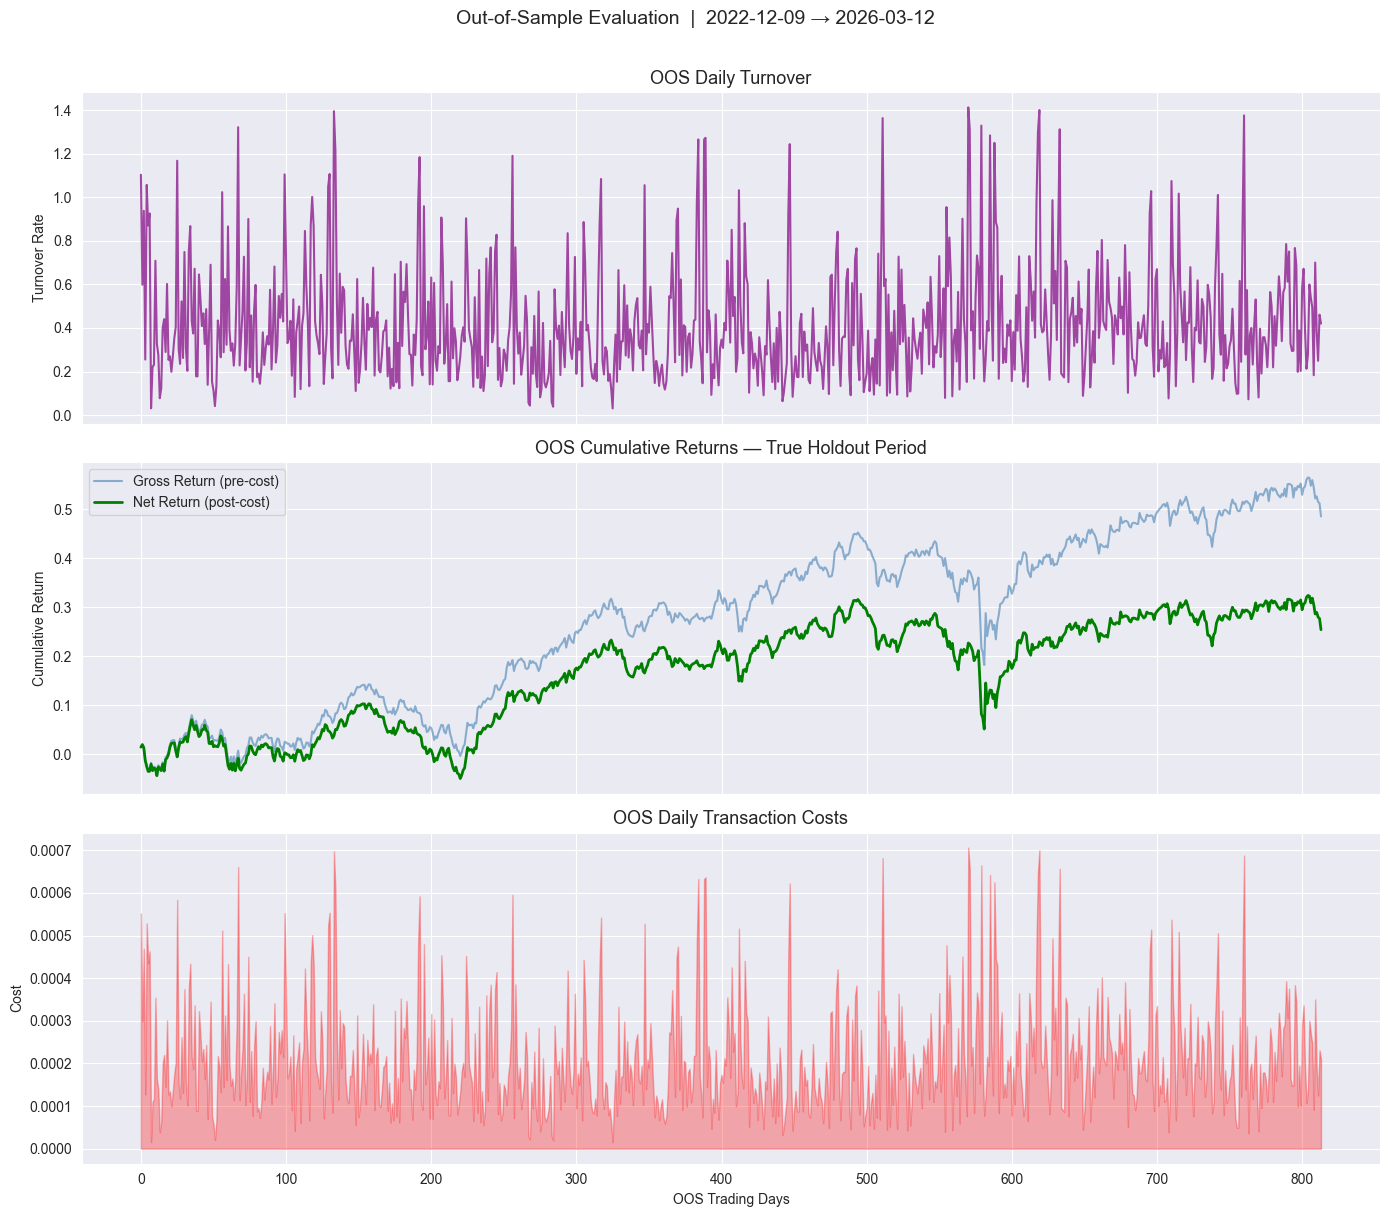

OOS Gross Return       : 48.52%
OOS Transaction Costs  : 16.91%
OOS Net Return         : 25.42%
OOS Sharpe (approx)    : 0.54


In [49]:
import matplotlib.pyplot as plt
import seaborn as sns

# ==============================================================================
# Step 4: Evaluation Setup — sync normalisation stats, lock test env
# ==============================================================================
print("Building OOS test environment with frozen normalisation stats...")

vec_test_env = DummyVecEnv([lambda: test_env])
vec_test_env = VecNormalize(
    vec_test_env,
    norm_obs=True,
    norm_reward=False,   # reward normalisation disabled for eval
    clip_obs=10.0,
)

# CRITICAL: copy running mean/var from training env so observations are
# normalised with the same statistics the policy was trained on.
vec_test_env.obs_rms   = vec_train_env.obs_rms
vec_test_env.ret_rms   = vec_train_env.ret_rms

# Lock the test env: no stat updates during rollout (prevents data leakage).
vec_test_env.training   = False
vec_test_env.norm_reward = False

# ==============================================================================
# Step 5: OOS Evaluation Loop
# ==============================================================================
print("Running OOS evaluation rollout...")

obs = vec_test_env.reset()
terminated = False
truncated  = False

oos_rewards           = []
oos_portfolio_returns = []
oos_turnovers         = []
oos_transaction_costs = []

while not (terminated or truncated):
    action, _ = model.predict(obs, deterministic=True)
    obs, reward, done, info = vec_test_env.step(action)

    # DummyVecEnv returns arrays; unwrap scalar values
    oos_rewards.append(float(reward[0]))
    oos_portfolio_returns.append(float(info[0]['portfolio_return']))
    oos_turnovers.append(float(info[0]['turnover']))
    oos_transaction_costs.append(float(info[0]['transaction_cost']))

    terminated = bool(done[0])

print(f"OOS rollout complete — {len(oos_rewards)} steps evaluated.")

# ==============================================================================
# Step 6: OOS Performance Visualisation
# ==============================================================================
sns.set_style("darkgrid")
fig, axes = plt.subplots(3, 1, figsize=(14, 12), sharex=True)

steps = range(len(oos_rewards))

# Panel 1: Turnover
axes[0].plot(steps, oos_turnovers, color='purple', alpha=0.7)
axes[0].set_title("OOS Daily Turnover", fontsize=13)
axes[0].set_ylabel("Turnover Rate")

# Panel 2: Cumulative gross vs net return (COMPOUNDED, not summed)
cum_gross = np.cumprod(1 + np.array(oos_portfolio_returns)) - 1
cum_net   = np.cumprod(1 + np.array(oos_rewards)) - 1
axes[1].plot(steps, cum_gross, label='Gross Return (pre-cost)', color='steelblue', alpha=0.6)
axes[1].plot(steps, cum_net,   label='Net Return (post-cost)',  color='green',     linewidth=2)
axes[1].set_title("OOS Cumulative Returns — True Holdout Period", fontsize=13)
axes[1].set_ylabel("Cumulative Return")
axes[1].legend()

# Panel 3: Daily transaction costs
axes[2].fill_between(steps, oos_transaction_costs, color='red', alpha=0.3)
axes[2].set_title("OOS Daily Transaction Costs", fontsize=13)
axes[2].set_xlabel("OOS Trading Days")
axes[2].set_ylabel("Cost")

plt.suptitle(
    f"Out-of-Sample Evaluation  |  {test_dates.min().date()} → {test_dates.max().date()}",
    fontsize=14, y=1.01
)
plt.tight_layout()
plt.show()

# Compounded total returns
total_gross = (1 + np.array(oos_portfolio_returns)).prod() - 1
total_tc    = np.sum(oos_transaction_costs)
total_net   = (1 + np.array(oos_rewards)).prod() - 1

# Annualised Sharpe on log returns for consistency
oos_rewards_arr = np.array(oos_rewards)
sharpe = np.mean(oos_rewards_arr) / (np.std(oos_rewards_arr) + 1e-9) * np.sqrt(252)

print(f"OOS Gross Return       : {total_gross*100:.2f}%")
print(f"OOS Transaction Costs  : {total_tc*100:.2f}%")
print(f"OOS Net Return         : {total_net*100:.2f}%")
print(f"OOS Sharpe (approx)    : {sharpe:.2f}")